In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [38]:
df = pd.read_csv("Mall_Customers.csv")
print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Loaded 200 rows and 5 columns


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


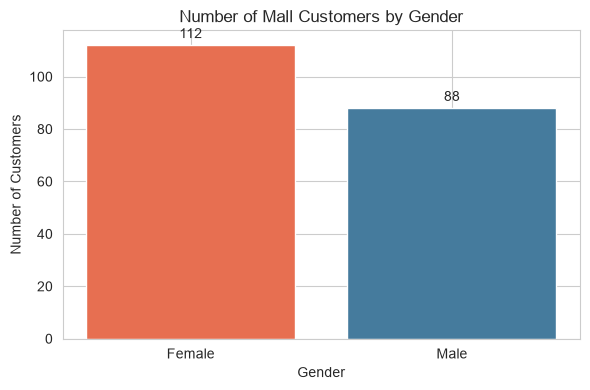

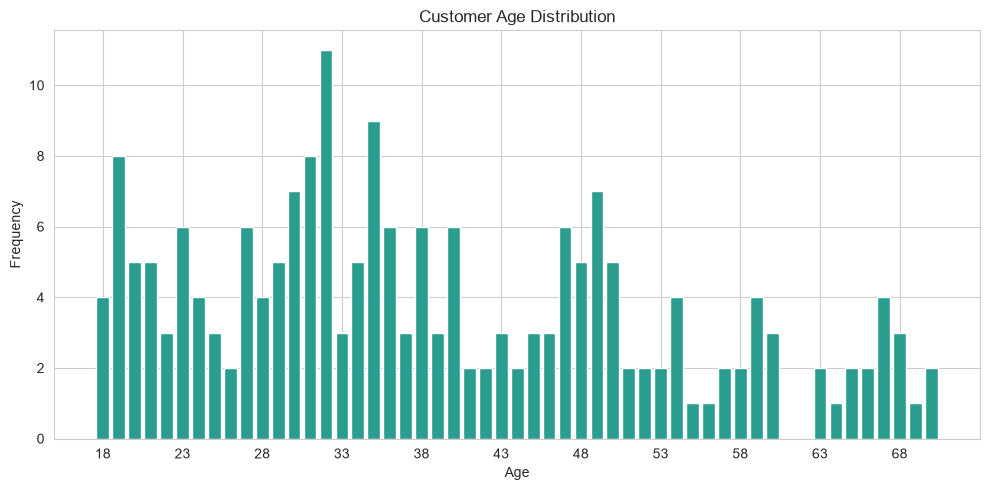

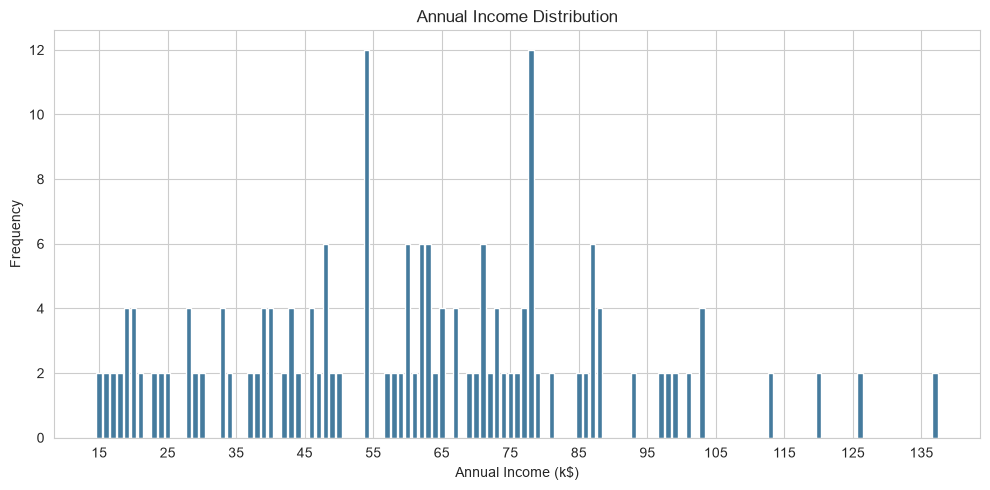

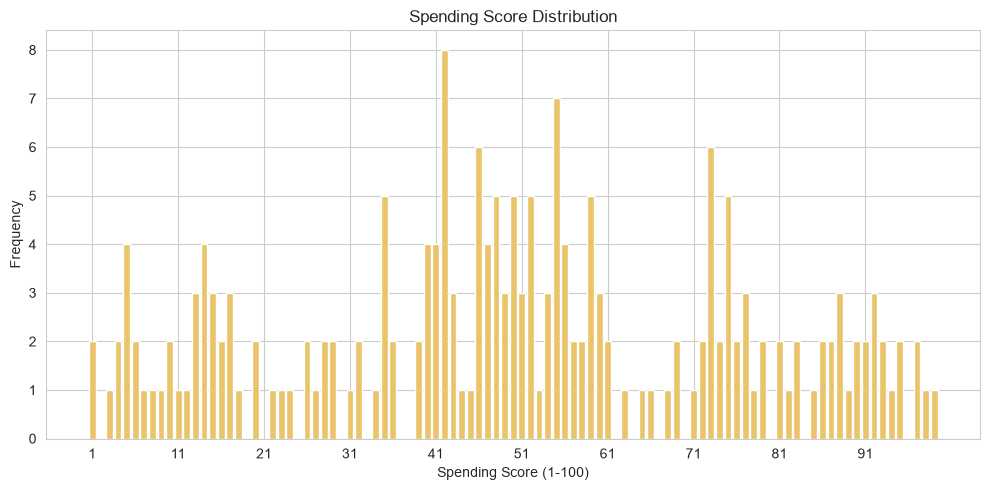

In [39]:
gender_counts = df["Gender"].value_counts().sort_index()
gender_colors = {"Female": "#e76f51", "Male": "#457b9d"}

plt.figure(figsize=(6, 4))
bars = plt.bar(gender_counts.index, gender_counts.values,
        color=[gender_colors.get(gender, "#6c757d") for gender in gender_counts.index])
plt.bar_label(bars, padding=3)
plt.title("Number of Mall Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

age_counts = df["Age"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(age_counts.index, age_counts.values, width=0.8, color="#2a9d8f")
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.xticks(range(int(age_counts.index.min()), int(age_counts.index.max()) + 1, 5))
plt.tight_layout()
plt.show()

income_counts = df["Annual Income (k$)"].value_counts().sort_index()
plt.figure(figsize=(10, 5))
plt.bar(income_counts.index, income_counts.values, width=0.8, color="#457b9d")
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")
plt.xticks(np.arange(int(income_counts.index.min()), int(income_counts.index.max()) + 1, 10))
plt.tight_layout()
plt.show()

spending_counts = df["Spending Score (1-100)"].value_counts().sort_index()
plt.figure(figsize=(10, 5))
plt.bar(spending_counts.index, spending_counts.values, width=0.8, color="#e9c46a")
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Frequency")
plt.xticks(np.arange(int(spending_counts.index.min()), int(spending_counts.index.max()) + 1, 10))
plt.tight_layout()
plt.show()

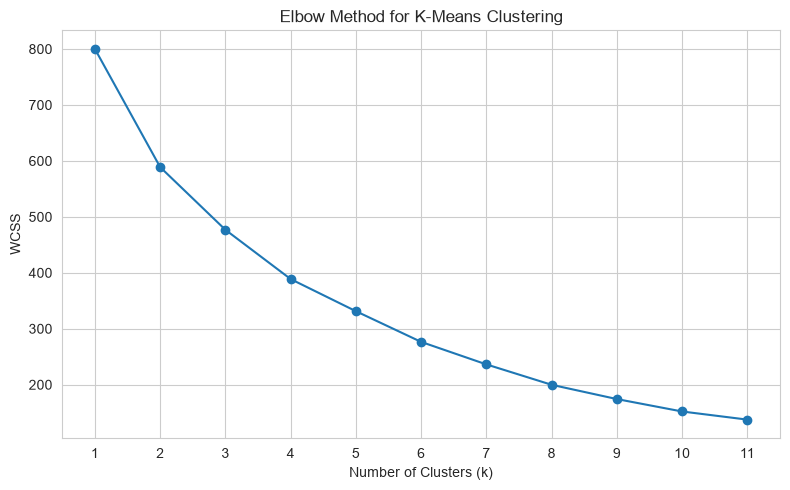

In [41]:
features = df.drop(columns=["CustomerID"])
features = pd.get_dummies(features, columns=["Gender"], drop_first=True, dtype=float)
X = StandardScaler().fit_transform(features)

wcss = []
k_values = range(1, 12)

for k in k_values:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker="o")
plt.title("Elbow Method for K-Means Clustering")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
optimal_k = 5
kmeans_5 = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
df["Cluster"] = kmeans_5.fit_predict(X)

print("Customer counts per cluster:")
print(df["Cluster"].value_counts().sort_index())
df.head()

Customer counts per cluster:
Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,3
2,3,Female,20,16,6,3
3,4,Female,23,16,77,3
4,5,Female,31,17,40,3


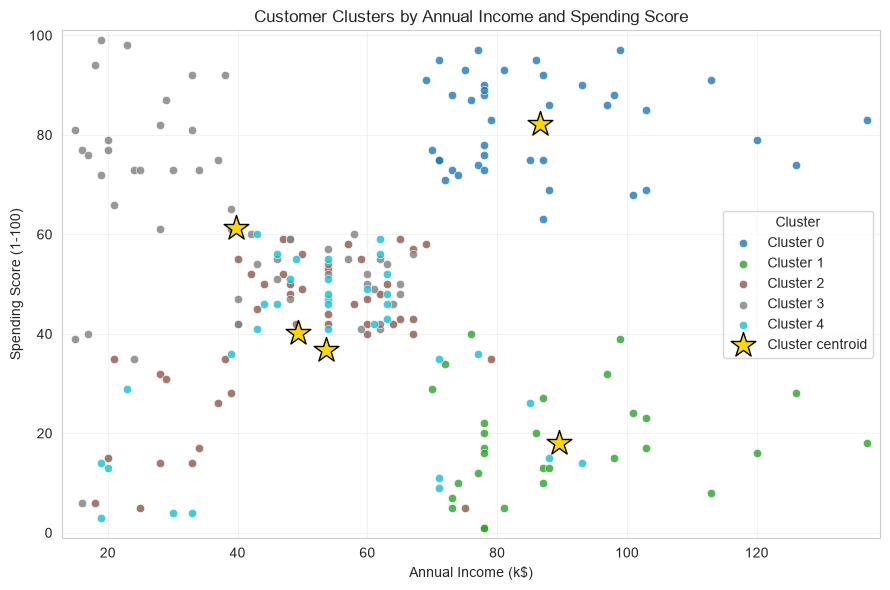

In [43]:
plt.figure(figsize=(9, 6))
cluster_colors = plt.get_cmap("tab10", optimal_k)

for cluster in sorted(df["Cluster"].unique()):
    cluster_data = df[df["Cluster"] == cluster]
    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        color=cluster_colors(cluster),
        label=f"Cluster {cluster}",
        alpha=0.8,
        edgecolor="white",
        linewidth=0.5,
        zorder=2
    )

cluster_centroids = df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()
plt.scatter(
    cluster_centroids["Annual Income (k$)"],
    cluster_centroids["Spending Score (1-100)"],
    marker="*",
    s=350,
    color="gold",
    edgecolor="black",
    linewidth=1,
    label="Cluster centroid",
    zorder=3
)

plt.title("Customer Clusters by Annual Income and Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.xlim(df["Annual Income (k$)"].min() - 2, df["Annual Income (k$)"].max() + 2)
plt.ylim(df["Spending Score (1-100)"].min() - 2, df["Spending Score (1-100)"].max() + 2)
plt.legend(title="Cluster")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

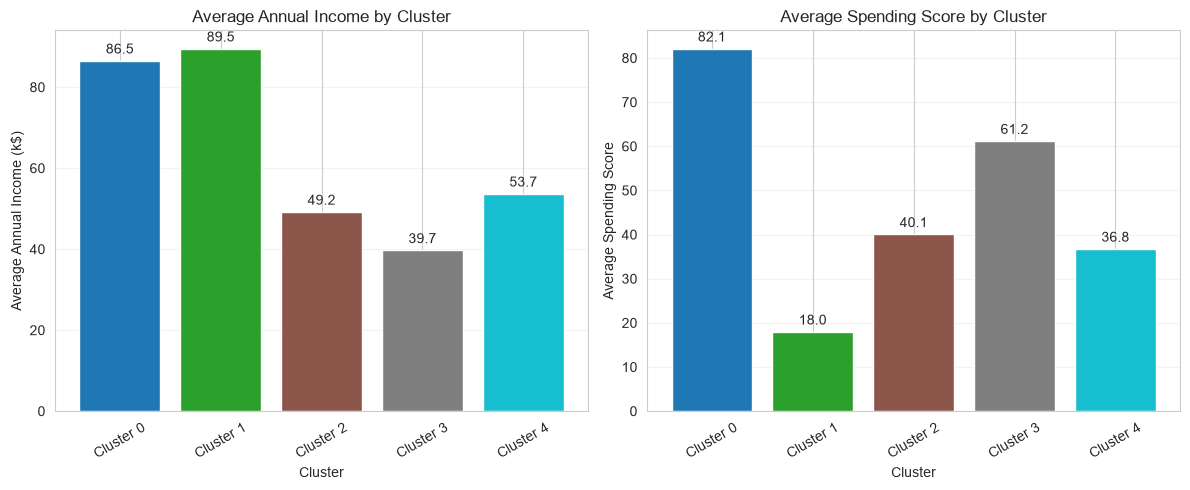

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,86.538462,82.128205
1,89.517241,18.000000
2,49.232558,40.069767
3,39.722222,61.203704
4,53.685714,36.771429


In [44]:
cluster_means = df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()
cluster_labels = [f"Cluster {cluster}" for cluster in cluster_means.index]
cluster_bar_colors = [cluster_colors(cluster) for cluster in cluster_means.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

income_bars = axes[0].bar(cluster_labels, cluster_means["Annual Income (k$)"], color=cluster_bar_colors)
axes[0].bar_label(income_bars, fmt="%.1f", padding=3)
axes[0].set_title("Average Annual Income by Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Average Annual Income (k$)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.25)

spending_bars = axes[1].bar(cluster_labels, cluster_means["Spending Score (1-100)"], color=cluster_bar_colors)
axes[1].bar_label(spending_bars, fmt="%.1f", padding=3)
axes[1].set_title("Average Spending Score by Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Average Spending Score")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()
cluster_means

In [45]:
model_features = ["Annual Income (k$)", "Spending Score (1-100)"]
scaler_2d = StandardScaler()
X_2d = scaler_2d.fit_transform(df[model_features])

kmeans_2d = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_2d.fit(X_2d)

model_bundle = {
    "model": kmeans_2d,
    "scaler": scaler_2d,
    "features": model_features,
}
joblib.dump(model_bundle, "customer-segmentation.pkl")
print("Saved income/spending K-Means model to customer-segmentation.pkl")

Saved income/spending K-Means model to customer-segmentation.pkl
